# Camera Pose Estimation for Tennis Match - UE Synthetic Data

This notebook documents a reproducible pipeline for estimating camera pose in tennis match footage using court-line segmentation. We leverage synthetically annotated data generated in Unreal Engine to avoid manual labeling, significantly reducing human annotation effort.

The notebook focuses on the deep-learning and computer vision components and algorithms of the workflow: model architecture, training, and inference. We also illustrate how the trained model can be applied to a real-world sports scenario — a recent Australian Open match between Alcaraz and Paul.

<p align="center">
    <img src="../rsc/render1frame0016.png" alt="synthetic_image" height = "350" width="600">
    <img src="../rsc/inference_example.png" alt="real_infernece_image" height = "350" width="600">
</p>

### Roadmap

1. Model: design and implementation of the CNN segmentation architecture
2. Training: dataset preparation (UE synthetic data), training pipeline using PyTorch, and evaluation metrics
3. Inference: segmentation-to-pose pipeline, post-processing algorithms, and application to a real match

## 1. U-Net - Deep Learning architecture for Image Segmentation
<p align="center">
    <img src="../rsc/u-net-architecture.png" alt="U-Net" height = "350" width="600">
    <img src="../rsc/road-Unet.jpg" alt="U-Net" height = "350" width="600">
</p>


U-Net is a convolutional neural network architecture designed for image segmentation, especially in biomedical applications. It follows an encoder–decoder structure: the contracting path (encoder) captures context through successive convolution and pooling layers, while the expansive path (decoder) enables precise localization by upsampling feature maps. A key feature of U-Net is the use of skip connections that link corresponding layers in the encoder and decoder, allowing the model to combine low-level spatial information with high-level semantic features. This design makes U-Net highly effective for tasks requiring accurate pixel-level predictions, even with limited training data.



In [27]:
"""The first thing we want is to load the synthetic tennis dataset with the image
and the corresponding mask from our demo dataset for this notebook"""

import torch
from torch.utils.data import Dataset
from PIL import Image
import os
import numpy as np


class TennisDemoDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_transform = None):
        super().__init__()
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_transform = img_transform
        self.img_files = sorted(os.listdir(img_dir))
        self.mask_files = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.img_files)
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        if self.img_transform:
            image = self.img_transform(image)
        mask = torch.from_numpy(np.array(mask)).long() # we dont want to use image transform if there is resize cause maybe destroys the interpolation between pixels in the mask
        return image, mask



In [28]:
"""The next step that we want to do is to create the layers of the model.
From the encoder, to the botteleneck, to the decoder. We will use the classic UNet architecture as we said."""

import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU()
        )
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.down(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.double_conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.double_conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [29]:
"""With the previous layers defined, we can now define the UNet architecture."""

class Unet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.out = OutConv(64, num_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        u1 = self.up1(x5, x4)
        u2 = self.up2(u1, x3)
        u3 = self.up3(u2, x2)
        u4 = self.up4(u3, x1)
        return self.out(u4)


## 2. Training Pipeline for U-Net on a Custom Dataset

This section describes the end-to-end training pipeline used to train the U-Net architecture from scratch on a custom demo dataset(30 images and 30 masks). It covers the key steps involved, including data loading and preprocessing, dataset splitting, and the application of data augmentation techniques to improve generalization. The section also outlines the model configuration, loss function, and optimization strategy, followed by the implementation of the training and validation loops. Finally, it presents the evaluation metrics used to assess performance, including training and validation loss as well as Intersection over Union (IoU) to measure pixel-wise prediction accuracy.

<p align = "center">
    <img src="../rsc/CNN_Training_Loop.jpg" alt="forward_backward propagation" height = "400" width="700">
</p>



In [30]:
"""First of all, we want to create a function that can evaluate the model precision.
We will use the Intersection over Union (IoU) metric for this purpose. This metric is
defined as the area of overlap between the predicted segmentation and the ground truth."""


def iou(preds, ground_truth, num_classes, ignore_index=0):
    if preds.dim() == 4:
        preds = torch.argmax(preds, dim=1)
    ious = []

    for cls in range(num_classes):
        if cls == ignore_index: ## this is if you want to ignore a specific pixel value, 0 is background class(black pixel)
            continue

        preds_cls = (preds == cls)
        ground_truth_cls = (ground_truth == cls)
        intersection = (preds_cls & ground_truth_cls).sum().item()
        union = (preds_cls | ground_truth_cls).sum().item()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    miou = torch.tensor(ious).nanmean().item() # mean ignoring nans values and returns a float of array
    return miou, ious

In [31]:
"""The next step is to create the pipeline for training de model"""


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### the ideal pipeline is to train the model with a gpu integrated for better performance, reducing training and inference

Using device: cuda


In [32]:
from torchvision import transforms
from torch.utils.data import DataLoader

"""An ideal dataset for training is to get a good variety of images, to avoid
overfitting and to make the model more robust. For this reason, we can apply
some data augmentation techniques to the images. This will help the model to
generalize better and to be more robust to different variations of the input images.
"""

img_transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ], p=0.25),
        transforms.RandomGrayscale(p=0.25),
        transforms.ToTensor(),
    ])



### We load de data
train_dataset = TennisDemoDataset(
    img_dir="../data/test_rsc/train/images",
    mask_dir="../data/test_rsc/train/masks",
    img_transform=img_transform)

val_dataset = TennisDemoDataset(
    img_dir="../data/test_rsc/valid/images",
    mask_dir="../data/test_rsc/valid/masks",
    img_transform = img_transform)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

In [33]:
"""For the training loop, we will use the Adam optimizer and the Cross Entropy Loss as the loss function.
For this notebook, we will train the model for a fixed number of epochs. In a real scenario, we would
train the model with more epochs with early stoppin to avoid overfitting. And with a large dataset.
Larger dataset -> better performance, but also more computational resources and time for training.
"""

from tqdm import tqdm # visualize the training progress with a progress bar

model = Unet(in_channels=3, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    """Training loop"""

    model.train()
    train_loss = 0.0

    print("Training...")
    for idx, (images, masks) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_average_loss = train_loss / (idx + 1)

    """Validation loop"""
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for idx, (images, masks) in enumerate(tqdm(val_loader)):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())

    val_average_loss = val_loss / (idx + 1)
    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)

    miou, ious = iou(all_preds, all_masks, num_classes=10, ignore_index=0)

    print(f"Epoch {epoch}")
    print(f"Train Loss: {train_average_loss:.4f}, Val Loss: {val_average_loss:.4f}")
    print(f"mIoU %: {miou * 100:.4f}")

print("Training completed")
##print("model saved")
##torch.save(model.state_dict(), "unet_tennis_demo.pth")
## How to save the model state dict. Saving state you will have to load arquitectura at inference.
## If not, you can save the entire model, but it is not recommended because it is less flexible, higher memory usage, and more prone to errors when loading.

Training...


100%|██████████| 10/10 [00:03<00:00,  2.60it/s]


Epoch 0
Train Loss: 2.3235, Val Loss: 2.2285
mIoU %: 0.0318
Training...


100%|██████████| 10/10 [00:03<00:00,  2.55it/s]


Epoch 1
Train Loss: 1.3149, Val Loss: 0.3969
mIoU %: 0.0000
Training...


...

Epoch 7
Train Loss: 0.1704, Val Loss: 0.2352
mIoU %: 0.0000
Training...


100%|██████████| 10/10 [00:04<00:00,  2.48it/s]


Epoch 8
Train Loss: 0.1650, Val Loss: 0.2453
mIoU %: 0.0000
Training...


100%|██████████| 10/10 [00:03<00:00,  2.63it/s]


Epoch 9
Train Loss: 0.1587, Val Loss: 0.2466
mIoU %: 0.0000
Training completed


*Note: Cause this is a demo notebook with a small dataset and probably few variability, you can see at the results of the training that even the loss is updating, IoU do not increase the percentage of validation with the ground truth. But with a larger dataset that can get higher values(0-100%, being 0 wrong training and 100 perfect training)*

## 3. Inference Pipeline: From Model Predictions to Real-Time Camera Pose Estimation in Tennis Broadcasts

This section presents the inference pipeline of the trained U-Net model, detailing how predictions are generated from input data and processed for practical use. It explains the steps required to perform efficient inference and visualize the segmentation results. Furthermore, the section extends this pipeline to a real-world computer vision application, demonstrating how the model’s outputs can be leveraged to estimate camera pose in real time during a tennis broadcast. This highlights the transition from a standalone model to an applied system in a dynamic sports environment.

<p align = "center">
    <img src="../rsc/render1frame0016.png" alt="synthetic image" height = "350" width="600">
    <img src="../rsc/render1frame0016mask.png" alt="synthetic mask" height = "350" width="600">
</p>
<p align = "center">
    <img src="../rsc/inference_example.png" alt="synthetic image" height = "350" width="600">
</p>


In [34]:
"""The first step is to load the model state dict and the architecture. Then we can use the model for inference."""

model = Unet(in_channels=3, num_classes=10).to(device)
model.load_state_dict(torch.load("../models/unet_modelV1.pth", map_location=device)) # for this notebook we will load a first version of the final model with a larger dataset. Version number 1

<All keys matched successfully>

GPU Inference time: 167.15 ms


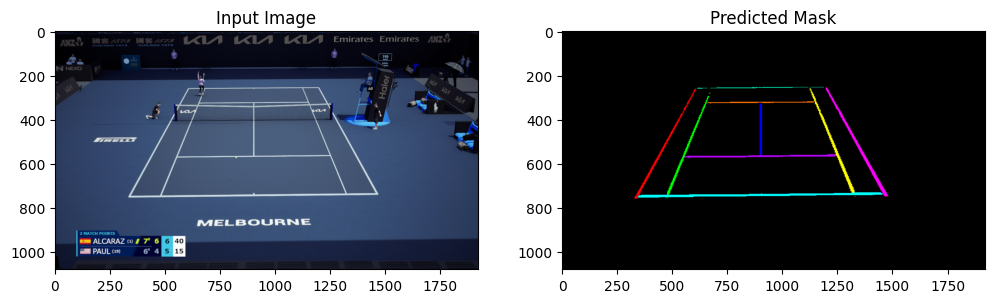

In [35]:
"""We are going to work firstly with the synthetic data, for 2 reasons:
1. We want to test the model with the synthetic data, to see how it performs with the data it was trained on.
2. Before we get on a real scenario to calculate the camera pose, cause we now which is the position of the Unreal Engine Camera when we generate the synthetic data
we can compare the predicted camera pose with the 3D engine camera."""

import time
from matplotlib import pyplot as plt
import cv2

model.eval()
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
]) # we need to set the image as the same resolution we trained the model, and set it to tensor for the model input

image = Image.open("../rsc/render1frame0016.png").convert("RGB")
tensor_image = transform(image).unsqueeze(0).to(device) # add batch dimension and move to device
with torch.no_grad():
    for _ in range(2):
        _ = model(tensor_image) #warm up the model
    torch.cuda.synchronize()
    start = time.time()
    output = model(tensor_image)
    torch.cuda.synchronize()
    end = time.time()
    print(f'GPU Inference time: {(end - start)*1000:.2f} ms')
    # we use torch.cuda.synchronize() to make sure that the GPU has finished the inference before we stop the timer, because the GPU works asynchronously with the CPU.
    # Cause my hardware is limited -> GTX 1650 Ti laptop, the inference time is around 100 ms, which is not real-time(16ms for 60fps)
    # With a modern GPU, the inference can 8x - 10x faster, so it can be around 10-12 ms

predicted_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)
predicted_mask_color = np.zeros((image.height, image.width, 3), dtype=np.uint8)

# Cause I now which pixel value corresponds to each class, I can set a color for each class for visualization

inference_color_palette = {
    0: (0, 0, 0),       # Background
    1: (255, 0, 0),     # Class 1
    2: (0, 255, 0),     # Class 2
    3: (0, 0, 255),     # Class 3
    4: (255, 255, 0),   # Class 4
    5: (255, 0, 255),   # Class 5
    6: (0, 255, 255),   # Class 6
    7: (186, 0, 255),   # Class 7
    8: (255, 113, 0),   # Class 8
    9: (0, 221, 162),   # Class 9
}

for class_index, color in inference_color_palette.items():
    predicted_mask_color[predicted_mask_resized == class_index] = color

pred_mask_image = Image.fromarray(predicted_mask_color)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(pred_mask_image)



*Note: Is not the better model version i have, but for this notebook is more than good for the explanation. As we see, we can have the lines segmented from a tennis court this a segmentation model, having lines information instead of maybe another architecture with keypoints information*

At this stage, the focus shifts to determining which geometric approach is most suitable for estimating the camera pose from the inferred segmentation. Two classical computer vision methods were considered: **homography** estimation and **Perspective-n-Point** (PnP). While both approaches can recover camera pose under certain conditions, **homography** was **selected** due to its suitability for planar scenes such as a tennis court. By estimating the homography between the image and the court plane, it is possible to recover intrinsic properties such as the effective focal length, which can then be used to approximate the camera’s field of view (**FOV**). This makes homography a practical and efficient choice for the intended application. Knowing world points and 2D points you can estimate the homography matrix.

<p align = "center">
    <img src="../rsc/Homography_Explanation.jpg" alt="homography explanation" height = "350" width="800">
    <img src="../rsc/Homography_tennis_visualization.png" alt="tennis visualization" height = "350" width="800">
</p>


So having our predicted mask, we can now define our roadmap for the next steps:
1. We need to map 3D world points to 2D image points. For this we can define the tennis court dimensions officials
<p align = "left">
    <img src="../rsc/tennis_court_dimensions.png" alt="tennis court" height = "300" width="500">
</p>

2. Calculate the intersection that we know between the predicted lines to map the real points
3. Calculate the homography matrix(H)
4. Find the ideal focal length to get the K(intrinsic camera matrix) because if not the homography matrix will not be accurate, and the camera pose estimation will be wrong.
5. With the intrisic camera matrix and the homography matrix, we can decompose the homography matrix to get the rotation, traslation and FOV of the camera.

*Note: For this project we assume that the camera lens has not distortion, because that can affect to the estimation. But at TV cameras, the distortion is usually low, so we are
going to get ~values that are very close to the real camera pose*

In [36]:
# 1. Mapping

intersections_lines = {
    1: (1,6),
    2: (1,7),
    3: (1,8),
    4: (1,9),
    5: (2,6),
    6: (2,7),
    7: (2,8),
    8: (2,9),
    9: (3,6),
    10: (3,7),
    11: (3,8),
    12: (3,9),
    13: (4,6),
    14: (4,7),
    15: (4,8),
    16: (4,9),
    17: (5,6),
    18: (5,7),
    19: (5,8),
    20: (5,9)
}

real_world_points = {
    1: (-5.485, -11.885),
    2: (-5.485, -6.4),
    3: (-5.485, 6.4),
    4: (-5.485, 11.885),
    5: (-4.115, -11.885),
    6: (-4.115, -6.4),
    7: (-4.115, 6.4),
    8: (-4.115, 11.885),
    9: (0.0, -11.885),
    10: (0.0, -6.4),
    11: (0.0, 6.4),
    12: (0.0, 11.885),
    13: (4.115, -11.885),
    14: (4.115, -6.4),
    15: (4.115, 6.4),
    16: (4.115, 11.885),
    17: (5.485, -11.885),
    18: (5.485, -6.4),
    19: (5.485, 6.4),
    20: (5.485, 11.885)
}


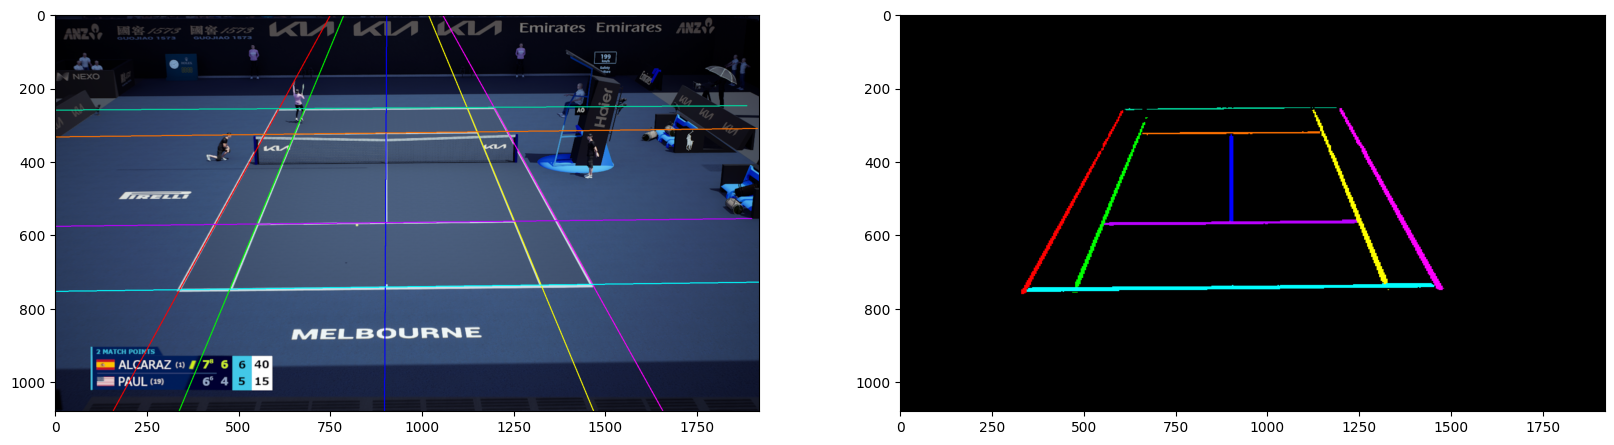

In [37]:
# 2. Calculate the lines
# IMPORTANT: We need to make the estimation with the frame without resize for inference, so after we get the predicted mask, we resized it to the original image size. We use mask resized


import cv2

lines = {}
intersections = {}
image_np = np.array(image)

for class_index, color in inference_color_palette.items():
    if class_index == 0:
        continue
    mask_binary = (predicted_mask_resized == class_index).astype(np.uint8)# this is because openCV function 'findContours' works with binary images
    if np.count_nonzero(mask_binary) < 10: # this is because we want to filter negative predictions at the image
        continue
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        continue
    contour = max(contours, key=cv2.contourArea)
    [vx, vy, x, y] = cv2.fitLine(contour, cv2.DIST_L2, 0, 0.01, 0.01)
    vx , vy, x, y = vx.item(), vy.item(), x.item(), y.item()
    lines[class_index] = (vx, vy, x, y)
    cv2.line(image_np, (int(x - vx * 1000), int(y - vy * 1000)), (int(x + vx * 1000), int(y + vy * 1000)), color, 2)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.subplot(1, 2, 2)
plt.imshow(predicted_mask_color)

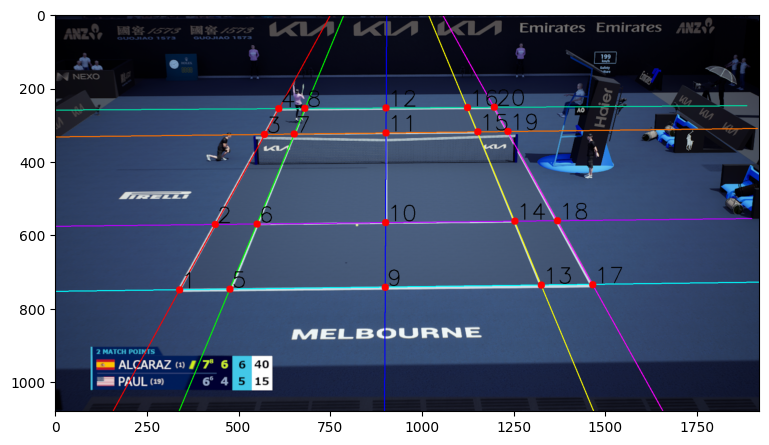

In [38]:
# 3. Calculate the intersection points between the lines that we want to map to real world coordinates

for index, (c1, c2) in intersections_lines.items():
    if c1 in lines and c2 in lines:
        ### we calculate the values for the intersection between to lines
        vx1, vy1, x1, y1 = lines[c1]
        vx2, vy2, x2, y2 = lines[c2]
        A = np.array([[vx1, -vx2], [vy1, -vy2]])
        b = np.array([x2 - x1, y2 - y1])
        t, s = np.linalg.solve(A, b) # you can use t or s, depend on with you want to multiply the direction vector
        x_int = int(x2 + vx2 * s)
        y_int = int(y2 + vy2 * s)
        intersections[index] = (x_int, y_int)
        cv2.circle(image_np, (x_int, y_int), 10, (255, 0, 0), -1)
        cv2.putText(image_np, f"{index}", (x_int + 5, y_int - 5), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_np)

In [39]:
# 4. Now we have the intersection points in pixel coordinates, and we have the corresponding real world coordinates. We can estimate Homography.


number_intersections = sorted(intersections.keys() & real_world_points.keys())
img_pts = np.array([intersections[i] for i in number_intersections]) 
real_pts = np.array([real_world_points[i] for i in number_intersections])

if len(number_intersections) >= 4: # we need at least 4 points to calculate homography
    H,_ = cv2.findHomography(real_pts, img_pts) # real_pts before img_pts because we want to estimate real world on 2D image
    print("Homography matrix:")
    print(H)
else:
    print("Not enough intersection points to calculate homography.")

Homography matrix:
[[ 7.05622834e+01  2.37034508e+01  9.01074841e+02]
 [-8.70435528e-01 -7.39229331e+00  4.23692382e+02]
 [-1.30801486e-04  2.62476076e-02  1.00000000e+00]]


In this block, knowing the homography matrix, we want to search for the ideal focal length of the camera. Since we do not know the internal parameters of the lens every frame, we have to use the mathematical properties of rotation to "find" the f dinamically.
Also, we have the Unreal Engine Camera Values that we can finally compare with the estimated results:

* CAMERA HORIZONTAL FOV -> 41.151º
* CAMERA POSITION UNREAL ENGINE AXIS(XYZ) cm -> 58, 3500, 940
* CAMERA ROTATION UNREAL ENGINE AXIS(Roll, Pitch, Yaw) º -> 0.58 , -17, -89.3

In [40]:
# 5. Estimate Camera Pose and FOV from homography

# Since the H matrix is defined up to a scalem, we can normalize it to stabilize numerical computations before decomposing it.
from scipy.optimize import minimize_scalar

H_normalized = H / np.linalg.norm(H[:, 0])
# we asume that the center of the lens coincides with the center of the image:
cx = image.width / 2
cy = image.height / 2

h1 = H_normalized[:, 0]
h2 = H_normalized[:, 1]
h3 = H_normalized[:, 2]

f = None # none for the first frame and to initialize

def ideal_f(f):
    K = np.array([[f, 0, cx],
                  [0, f, cy],
                    [0, 0, 1]], dtype=np.float32)
    # The homography relates the camera to the world through the formula H ≈ K [r₁ | r₂ | t].
    #To isolate the rotation vectors (r₁, r₂), we multiply the columns of H by the inverse of the intrinsic matrix (K⁻¹), which is equivalent to “undoing” the lens distortion effect.
    K_inv = np.linalg.inv(K)
    r1 = K_inv @ h1
    r2 = K_inv @ h2

    # A Real Camera must satisfy two golden rules:
    # 1. The rotation vectors must be orthogonal: r₁ ⋅ r₂ = 0.
    # 2. Both axes should have the same scale: ||r₁|| = ||r₂||.

    ortho = np.dot(r1, r2)
    norm_diff = np.linalg.norm(r1) - np.linalg.norm(r2)
    return ortho**2 + 0.1 * norm_diff**2
    # We combine both errors (ortho² + 0.1 * norm_diff²).
    # The 0.1 is a weighting factor to balance both conditions so that one does not dominate the other purely due to numerical scale.

if f is not None:
    f_min = f * 0.5
    f_max = f * 1.5
    # stablished range of focal length to search for the optimal value
else:
    f_min = 100
    f_max = 5000

res = minimize_scalar(ideal_f, bounds=(f_min, f_max), method='bounded')
optimal_f = res.x
print(f"Focal Length: {optimal_f:.2f} pixels")

# minimize_scalar is a function from scipy that minimizes a scalar function of one variable
# We use the 'bounded' method because we want to search for the optimal focal length within a specific range

Focal Length: 2564.30 pixels


In [41]:
# With the optimal focal length, we can now compose again K and decompose the homography to get the camera pose

K = np.array([[optimal_f, 0, cx],
              [0, optimal_f, cy],
                [0, 0, 1]], dtype=np.float32)
K_inv = np.linalg.inv(K)
r1 = K_inv @ h1
r2 = K_inv @ h2
t = K_inv @ h3

L = 1/ np.linalg.norm(r1) # normalization factor to ensure that the rotation vectors have unit length
r1 *= L
r2 *= L
t *= L
# As the homography takes for granted Z axis = 0 and the camera pose need the 3 Axis (XYZ),
# we can calculate the third rotation vector as the cross product of the first two: r₃ = r₁ × r₂.

r3 = np.cross(r1, r2)
R = np.column_stack((r1, r2, r3)) # rotation matrix
# Now we apply the SVD decomposition to the rotation matrix R to ensure that it is a valid rotation matrix

U,_,Vt = np.linalg.svd(R)
R_ortho = U @ Vt
print("Rotation Matrix of the world:")
print(R_ortho)

C = -R_ortho.T @ t # camera center in world coordinates
print("Camera Position in meters:")
print(C.flatten())


# The rotation matrix R_ortho represents the orientation of the camera in the world coordinate system
# But we want the rotation from the world to the camera:

from scipy.spatial.transform import Rotation as Rot

R_wc = R_ortho.T
rot = Rot.from_matrix(R_wc)
rx, ry, rz = rot.as_euler('xyz', degrees=True)
cam_rotation = np.round([rx, ry, rz], 2)
print("Camera Rotation in degrees:")
print(cam_rotation)

# finally we got the ideal focal length in pixels, but normally that value is represented as FOV,
# so we can calculate the FOV with the formula: FOV = 2 * arctan((sensor_size / 2) / focal_length)

FOV_x = 2* np.arctan((cx) / optimal_f)
FOV_x_deg = np.rad2deg(FOV_x)
print("FOV Horizontal:")
print(FOV_x_deg)



Rotation Matrix of the world:
[[ 0.99987492 -0.01003772 -0.0122222 ]
 [-0.01470331 -0.30524689 -0.95215973]
 [ 0.00582673  0.95222034 -0.3053563 ]]
Camera Position in meters:
[  0.59788236 -35.05109651   9.49966818]
Camera Rotation in degrees:
[-107.78    0.7    -0.58]
FOV Horizontal:
41.048896370032146


In conclusion, this notebook demonstrates how camera pose and intrinsic parameters can be estimated directly from image geometry, without requiring prior calibration. By leveraging mathematical constraints such as orthogonality and scale consistency, we can recover meaningful physical properties of a broadcast camera in a robust and automated way. This approach is not limited to a specific scenario—it can be generalized to virtually any sport or broadcast setup where a planar field and known geometric structure are present. Ultimately, this enables the extraction of key camera parameters that can be reused for a wide range of broadcast applications, such as augmented graphics, player tracking, or tactical analysis.

Finally, if we compare the estimated results we can see that is correct, with a little tip. That OPENCV has not the same axis value as Unreal Engine, so we can multiply with a system coordinates matrix or directly adjust the values with offset depending on the axis that we are going to use.

Camera Position estimated(m):  0.59788236, -35.05109651, 9.49966818 -> Camera Position Unreal Engine(cm): 58, 3500, 940
Camera Rotation estimated(PYR): -107.78, 0.7, -0.58-> Camera Rotation Unreal Engine(RPY): 0.58 , -17, -89.3

Looking at the camera position is easier to see the match, but for the rotation you will need to swap axis values and multiply by -1

## 4. Transfer the pipeline to the real tennis match to see the results

Remember that we are goint to use a first version of the model but for this demo is more than better the version number 1

GPU Inference time: 163.99 ms


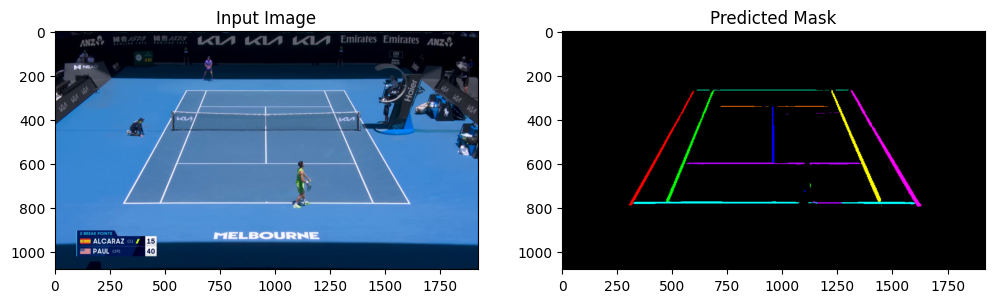

In [42]:
model.eval()

image = Image.open("../rsc/frame0019.png").convert("RGB")
tensor_image = transform(image).unsqueeze(0).to(device) # add batch dimension and move to device
with torch.no_grad():
    for _ in range(2):
        _ = model(tensor_image) #warm up the model
    torch.cuda.synchronize()
    start = time.time()
    output = model(tensor_image)
    torch.cuda.synchronize()
    end = time.time()
    print(f'GPU Inference time: {(end - start)*1000:.2f} ms')
    # we use torch.cuda.synchronize() to make sure that the GPU has finished the inference before we stop the timer, because the GPU works asynchronously with the CPU.
    # Cause my hardware is limited -> GTX 1650 Ti laptop, the inference time is around 100 ms, which is not real-time(16ms for 60fps)
    # With a modern GPU, the inference can 8x - 10x faster, so it can be around 10-12 ms

predicted_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
predicted_mask_resized = cv2.resize(predicted_mask.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)
predicted_mask_color = np.zeros((image.height, image.width, 3), dtype=np.uint8)

# Cause I now which pixel value corresponds to each class, I can set a color for each class for visualization

inference_color_palette = {
    0: (0, 0, 0),       # Background
    1: (255, 0, 0),     # Class 1
    2: (0, 255, 0),     # Class 2
    3: (0, 0, 255),     # Class 3
    4: (255, 255, 0),   # Class 4
    5: (255, 0, 255),   # Class 5
    6: (0, 255, 255),   # Class 6
    7: (186, 0, 255),   # Class 7
    8: (255, 113, 0),   # Class 8
    9: (0, 221, 162),   # Class 9
}

for class_index, color in inference_color_palette.items():
    predicted_mask_color[predicted_mask_resized == class_index] = color

pred_mask_image = Image.fromarray(predicted_mask_color)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(pred_mask_image)


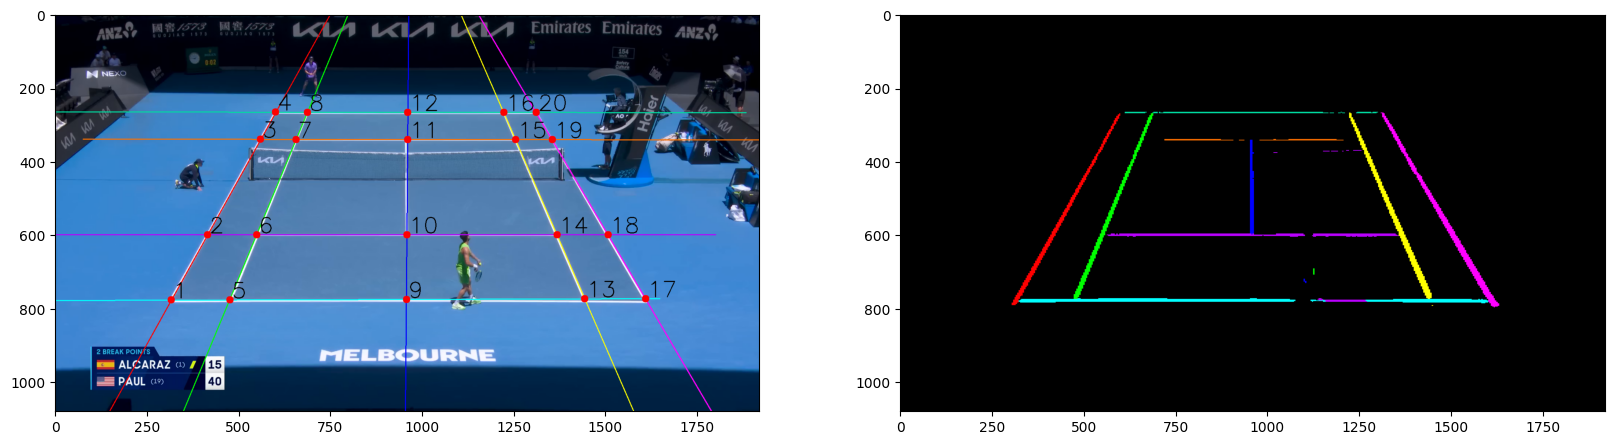

In [43]:
lines = {}
intersections = {}
image_np = np.array(image)

for class_index, color in inference_color_palette.items():
    if class_index == 0:
        continue
    mask_binary = (predicted_mask_resized == class_index).astype(np.uint8)# this is because openCV function 'findContours' works with binary images
    if np.count_nonzero(mask_binary) < 10: # this is because we want to filter negative predictions at the image
        continue
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        continue
    contour = max(contours, key=cv2.contourArea)
    [vx, vy, x, y] = cv2.fitLine(contour, cv2.DIST_L2, 0, 0.01, 0.01)
    vx , vy, x, y = vx.item(), vy.item(), x.item(), y.item()
    lines[class_index] = (vx, vy, x, y)
    cv2.line(image_np, (int(x - vx * 1000), int(y - vy * 1000)), (int(x + vx * 1000), int(y + vy * 1000)), color, 2)

for index, (c1, c2) in intersections_lines.items():
    if c1 in lines and c2 in lines:
        ### we calculate the values for the intersection between to lines
        vx1, vy1, x1, y1 = lines[c1]
        vx2, vy2, x2, y2 = lines[c2]
        A = np.array([[vx1, -vx2], [vy1, -vy2]])
        b = np.array([x2 - x1, y2 - y1])
        t, s = np.linalg.solve(A, b) # you can use t or s, depend on with you want to multiply the direction vector
        x_int = int(x2 + vx2 * s)
        y_int = int(y2 + vy2 * s)
        intersections[index] = (x_int, y_int)
        cv2.circle(image_np, (x_int, y_int), 10, (255, 0, 0), -1)
        cv2.putText(image_np, f"{index}", (x_int + 5, y_int - 5), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 0), 2)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.subplot(1, 2, 2)
plt.imshow(predicted_mask_color)



In [44]:
number_intersections = sorted(intersections.keys() & real_world_points.keys())
img_pts = np.array([intersections[i] for i in number_intersections]) 
real_pts = np.array([real_world_points[i] for i in number_intersections])

if len(number_intersections) >= 4: # we need at least 4 points to calculate homography
    H,_ = cv2.findHomography(real_pts, img_pts) # real_pts before img_pts because we want to estimate real world on 2D image
    print("Homography matrix:")
    print(H)
else:
    print("Not enough intersection points to calculate homography.")


H_normalized = H / np.linalg.norm(H[:, 0])
# we asume that the center of the lens coincides with the center of the image:
cx = image.width / 2
cy = image.height / 2

h1 = H_normalized[:, 0]
h2 = H_normalized[:, 1]
h3 = H_normalized[:, 2]

f = None # none for the first frame and to initialize

def ideal_f(f):
    K = np.array([[f, 0, cx],
                  [0, f, cy],
                    [0, 0, 1]], dtype=np.float32)
    # The homography relates the camera to the world through the formula H ≈ K [r₁ | r₂ | t].
    #To isolate the rotation vectors (r₁, r₂), we multiply the columns of H by the inverse of the intrinsic matrix (K⁻¹), which is equivalent to “undoing” the lens distortion effect.
    K_inv = np.linalg.inv(K)
    r1 = K_inv @ h1
    r2 = K_inv @ h2

    # A Real Camera must satisfy two golden rules:
    # 1. The rotation vectors must be orthogonal: r₁ ⋅ r₂ = 0.
    # 2. Both axes should have the same scale: ||r₁|| = ||r₂||.

    ortho = np.dot(r1, r2)
    norm_diff = np.linalg.norm(r1) - np.linalg.norm(r2)
    return ortho**2 + 0.1 * norm_diff**2
    # We combine both errors (ortho² + 0.1 * norm_diff²).
    # The 0.1 is a weighting factor to balance both conditions so that one does not dominate the other purely due to numerical scale.

if f is not None:
    f_min = f * 0.5
    f_max = f * 1.5
    # stablished range of focal length to search for the optimal value
else:
    f_min = 100
    f_max = 5000

res = minimize_scalar(ideal_f, bounds=(f_min, f_max), method='bounded')
optimal_f = res.x
print(f"Focal Length: {optimal_f:.2f} pixels")


K = np.array([[optimal_f, 0, cx],
              [0, optimal_f, cy],
                [0, 0, 1]], dtype=np.float32)
K_inv = np.linalg.inv(K)
r1 = K_inv @ h1
r2 = K_inv @ h2
t = K_inv @ h3

L = 1/ np.linalg.norm(r1) # normalization factor to ensure that the rotation vectors have unit length
r1 *= L
r2 *= L
t *= L
# As the homography takes for granted Z axis = 0 and the camera pose need the 3 Axis (XYZ),
# we can calculate the third rotation vector as the cross product of the first two: r₃ = r₁ × r₂.

r3 = np.cross(r1, r2)
R = np.column_stack((r1, r2, r3)) # rotation matrix
# Now we apply the SVD decomposition to the rotation matrix R to ensure that it is a valid rotation matrix

U,_,Vt = np.linalg.svd(R)
R_ortho = U @ Vt
print("Rotation Matrix of the world:")
print(R_ortho)

C = -R_ortho.T @ t # camera center in world coordinates
print("Camera Position in meters:")
print(C.flatten())


# The rotation matrix R_ortho represents the orientation of the camera in the world coordinate system
# But we want the rotation from the world to the camera:

from scipy.spatial.transform import Rotation as Rot

R_wc = R_ortho.T
rot = Rot.from_matrix(R_wc)
rx, ry, rz = rot.as_euler('xyz', degrees=True)
cam_rotation = np.round([rx, ry, rz], 2)
print("Camera Rotation in degrees:")
print(cam_rotation)

# finally we got the ideal focal length in pixels, but normally that value is represented as FOV,
# so we can calculate the FOV with the formula: FOV = 2 * arctan((sensor_size / 2) / focal_length)

FOV_x = 2* np.arctan((cx) / optimal_f)
FOV_x_deg = np.rad2deg(FOV_x)
print("FOV Horizontal:")
print(FOV_x_deg)


Homography matrix:
[[ 8.37225686e+01  2.30022829e+01  9.57238722e+02]
 [-1.37336156e-01 -8.78233175e+00  4.49248814e+02]
 [-1.12968141e-04  2.41845874e-02  1.00000000e+00]]
Focal Length: 3346.60 pixels
Rotation Matrix of the world:
[[ 9.99997589e-01  7.76508207e-04 -2.05413595e-03]
 [-1.78086493e-03 -2.60552703e-01 -9.65457983e-01]
 [-1.28489672e-03  9.65459313e-01 -2.60550692e-01]]
Camera Position in meters:
[  0.08230355 -38.82354627   9.35607365]
Camera Rotation in degrees:
[-1.051e+02  1.200e-01  4.000e-02]
FOV Horizontal:
32.01193398926903
